# 01: KuaiRec Sequence EDA for Long-Term Causal Effects

This notebook starts the Long-Term Causal Effects lab. The central problem is a common tension in recommender systems. A recommendation policy can increase immediate engagement while still hurting longer-term user value. A short video feed, news feed, or streaming homepage may learn to maximize near-term clicks, watch time, or completion rate. Those metrics are useful. They also leave a more strategic data science question. Does the exposure pattern caused by the recommender improve future retention, future engagement, and sustained long-run user value?

This is a causal question because normal logs assign content exposure through platform and user behavior. A user sees videos because the platform selected them, because the user has a history, because the user has preferences, and because prior engagement changes what the recommender does next. If we compare users who received high-engagement exposures against users with lower exposure, the difference may reflect the recommender's targeting logic.

The specific problem handled here is the **sequential causal inference setup** for KuaiRec.

- The unit is a user observed across multiple days.
- The time index is the calendar day.
- The observed state includes prior activity, prior watch behavior, and user metadata.
- The primary treatment developed across the lab is a short-term high-watch-exposure user-day. This first notebook also inspects broader candidate exposure definitions.
- The outcome is a future behavior measure, such as next-day activity or future multi-day engagement.
- The hard part is time-varying confounding: yesterday's engagement affects today's recommendations, and today's recommendations affect tomorrow's engagement.

This notebook prepares the panel structure needed for later causal estimation. It inspects whether KuaiRec has enough repeated user activity, date coverage, treatment variation, and future outcomes to support later notebooks on marginal structural models and g-computation. The practical question is whether this dataset can support a credible long-term causal effects project, and what the treatment and outcome definitions should look like.


## Project Framing

### What You Will Build

This project builds a sequential causal workflow for long-term effects in recommendation systems. You will reorganize KuaiRec interactions into user-day records, define short-term exposure histories and future engagement outcomes, then estimate long-term effects with weighting, marginal structural models, g-computation, and doubly robust methods.

### How To Use This Project

Work through the notebooks in order. This first notebook builds the panel and explains the user-time structure. Later notebooks define the estimand, handle time-varying confounding, estimate stabilized weights, compare longitudinal estimators, add doubly robust estimation, and study heterogeneous effects.

### Data Source And Scope

The analysis uses KuaiRec interaction logs. KuaiRec is useful here because it supports dense user-video evaluation, which helps construct longitudinal user-day summaries. The project remains observational, so the main teaching point is how sequential causal assumptions, diagnostics, and sensitivity analysis shape long-term recommendation claims.

<!-- dataset-experiment-context -->
## Dataset and Sequential Design Context

This project uses KuaiRec interaction logs organized into a user-day panel. The raw data contain user-video interactions, watch behavior, user features, item metadata, and item daily popularity information.

The data come from a real observational sequential recommendation log. Daily exposure was created by the recommender system, so assignment must be treated as time-varying and confounded. The treatment is a constructed high-watch-exposure day, the primary outcome is future seven-day engagement, and lagged user behavior is both a predictor of treatment and a predictor of future outcomes.

The project studies a sequential causal question: whether short-term exposure is associated with later engagement after adjusting for observed history. Marginal structural models, g-computation, doubly robust estimation, overlap diagnostics, and heterogeneity checks are used to decide whether the evidence is credible enough to motivate a future online test.

**Role of this notebook.** This notebook checks whether KuaiRec can support a user-day sequential causal design by studying repeated activity, timing, treatment variation, and future outcome availability.

<!-- mathematical-setup -->

## Mathematical Setup

This project uses panel-style user-day data. Let \(i\) index users and \(t\) index days. A short-term high-watch exposure treatment is \(A_{it}\), and a future engagement outcome is \(Y_{i,t+h}\). The observed history before treatment is

$$
H_{it}=\{X_i, A_{i,t-1}, Y_{i,t-1}, \ldots\}.
$$

The causal question asks whether changing exposure would change future engagement. It is whether changing exposure at time \(t\) would change a future outcome:

$$
\tau_h=\mathbb{E}\left[Y_{i,t+h}(1)-Y_{i,t+h}(0)\right].
$$

The EDA checks whether the panel has enough repeated observations, treatment variation, and outcome variation to make that question analyzable.


### Lab Roadmap

This notebook follows a causal data-understanding path. First, we load KuaiRec directly from the nested zip archive while keeping the full dataset compressed. Then we inspect the raw interaction fields, user metadata, item category metadata, and item daily popularity features. After that, we aggregate interactions into a user-day panel, because long-term causal effects require a time-indexed panel.

The most important output of the notebook is a reusable user-day table. Later notebooks can use this table to define treatment histories, estimate inverse probability weights, fit marginal structural models, and compare g-computation style estimates.


## Data Fields and Column Guide

This project uses KuaiRec as a sequential recommendation log. The raw data is spread across interaction, user, item-category, and item-daily-feature tables. The field guide below explains the columns before any analysis code runs, so the rest of the notebook is easier to read.

### User-Video Interaction Log

This is the main event-level table. Each row represents a user-video watch event.

| Column | Meaning | How it matters for this project |
|---|---|---|
| `user_id` | Unique user identifier. | Defines the panel unit. Long-term causal effects are studied by following each user over time. |
| `video_id` | Unique video identifier. | Identifies the item consumed or exposed in the recommendation environment. |
| `play_duration` | Amount of time the user played the video, stored in milliseconds. | Short-term engagement signal. Later aggregated into daily play duration and used to define future outcomes. |
| `video_duration` | Length of the video, stored in milliseconds. | Item context and denominator for watch-ratio calculations. |
| `time` | Human-readable event time string. | Used as a diagnostic event timestamp; the notebook also parses the Unix timestamp field. |
| `date` | Calendar date of the event, encoded like `20200705`. | Becomes the daily time index for the user-day panel. |
| `timestamp` | Unix timestamp of the event in seconds. | Used to reconstruct event ordering within users. |
| `watch_ratio` | `play_duration / video_duration`. Values above 1 can occur when users rewatch or exceed the nominal video length. | Core short-term engagement measure. Used to define high-watch exposure candidates and daily engagement summaries. |

### User Metadata

This table contains baseline user attributes and anonymized features. These columns can be used as baseline confounders because user characteristics may affect both what the recommender shows and how the user behaves later.

| Column | Meaning | How it matters for this project |
|---|---|---|
| `user_id` | Unique user identifier. | Join key from interaction rows to user-level attributes. |
| `user_active_degree` | Categorical user activity segment such as high-active or full-active. | Baseline activity segment; likely related to future retention and exposure patterns. |
| `is_lowactive_period` | Indicator for whether the user is in a low-activity period. | Baseline or period-level activity state. Useful for understanding heterogeneous retention risk. |
| `is_live_streamer` | Indicator for whether the user is a live streamer. | User role/context feature that may affect content preferences and future behavior. |
| `is_video_author` | Indicator for whether the user authors videos. | User role/context feature; creators may behave differently from pure consumers. |
| `follow_user_num` | Number of users this user follows. | Social graph intensity; possible proxy for platform embeddedness. |
| `follow_user_num_range` | Binned range version of `follow_user_num`. | Categorical version of follow count for modeling or stratified summaries. |
| `fans_user_num` | Number of fans/followers the user has. | Popularity or creator-context proxy. |
| `fans_user_num_range` | Binned range version of `fans_user_num`. | Categorical version of fan count. |
| `friend_user_num` | Number of friends connected to the user. | Social connectedness proxy; may predict retention. |
| `friend_user_num_range` | Binned range version of `friend_user_num`. | Categorical version of friend count. |
| `register_days` | Number of days since registration. | User tenure; important baseline confounder for future engagement. |
| `register_days_range` | Binned range version of `register_days`. | Categorical tenure feature. |
| `onehot_feat0` to `onehot_feat17` | Anonymized one-hot user features supplied by KuaiRec. | Potential baseline covariates. They are useful for prediction and adjustment. Their substantive meaning is anonymized in the public release. |

### Video Category Metadata

This table maps videos to one or more category identifiers.

| Column | Meaning | How it matters for this project |
|---|---|---|
| `video_id` | Unique video identifier. | Join key from interaction rows to video metadata. |
| `feat` | String representation of a list of category ids, such as `[27, 9]`. | Describes item content category. Later parsed into category count and first-category diagnostics. |

### Daily Video Popularity and Engagement Context

The full table has many daily item metrics. This notebook loads a focused subset that is directly useful for sequential recommendation diagnostics. These features can become item-day context variables because item popularity may affect both recommendation exposure and downstream user behavior.

| Column | Meaning | How it matters for this project |
|---|---|---|
| `video_id` | Unique video identifier. | Join key to connect daily item context to consumed videos. |
| `date` | Calendar date for the item-day metrics. | Aligns item popularity with the same daily panel used for users. |
| `show_cnt` | Number of times the video was shown. | Visibility/popularity proxy. A highly shown item may be more likely to appear in recommendation logs. |
| `show_user_num` | Number of users who were shown the video. | User-level reach of the item on that day. |
| `play_cnt` | Number of plays. | Daily item consumption volume. |
| `play_user_num` | Number of users who played the video. | Daily user reach among players. |
| `complete_play_cnt` | Number of complete plays. | Daily completion signal for the item. |
| `like_cnt` | Number of likes. | Positive feedback signal for the item. |
| `comment_cnt` | Number of comments. | Deeper engagement signal for the item. |
| `share_cnt` | Number of shares. | Viral or social engagement signal for the item. |
| `collect_cnt` | Number of collections/saves. | Longer-intent engagement signal for the item. |

### Derived Columns Created Later in This Lab

The notebook also creates derived fields after loading the raw data. These fields are central to the causal setup.

| Derived column family | Meaning |
|---|---|
| `event_date`, `event_time`, `event_timestamp` | Cleaned time fields used to order events and build daily panels. |
| `play_duration_sec`, `video_duration_sec` | Human-readable duration fields converted from milliseconds to seconds. |
| `high_watch`, `complete_or_rewatch` | Interaction-level engagement indicators based on watch-ratio thresholds. |
| `active_day`, `interactions`, `total_play_duration_sec`, `avg_watch_ratio` | User-day summaries used to describe daily state. |
| `lag_1_*`, `prior_3day_*` | Pre-treatment history variables used as time-varying confounder candidates. |
| `next_day_*`, `future_3day_*`, `future_7day_*` | Future outcome variables used to study longer-term engagement. |
| `treatment_high_intensity`, `treatment_high_watch_exposure` | First-pass daily treatment definitions used to inspect treatment variation and confounding. |


#### Setup

The first code cell imports the libraries used throughout the notebook. The plotting settings are kept simple and readable because this notebook is mostly about understanding temporal structure. We also make pandas show enough rows and columns for compact diagnostic tables.


In [1]:
from io import BytesIO
from pathlib import Path
from zipfile import ZipFile
import ast
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")


The notebook environment is now ready for sequential EDA: pandas handles the panel operations, seaborn and matplotlib handle visual checks, and the display settings make the wide diagnostic tables readable. The next step is to locate the project data in a way that works whether the notebook is run from the repository root or from inside the notebook folder.


#### Locate the Project and Data

This notebook may be run from the repository root or from inside the `notebooks/projects/project_3_long_term_causal_effects` folder. The next cell searches upward until it finds the KuaiRec archive. Keeping this path logic inside the notebook makes it easier to rerun from Jupyter while avoiding manual directory changes.


In [2]:
KUAI_REC_ZIP_RELATIVE_PATH = Path("data/Kuairec/18164998.zip")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / KUAI_REC_ZIP_RELATIVE_PATH).exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find {KUAI_REC_ZIP_RELATIVE_PATH}. Run this notebook from inside the ranking_sys project."
    )

KUAI_REC_ZIP = PROJECT_ROOT / KUAI_REC_ZIP_RELATIVE_PATH
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"KuaiRec archive: {KUAI_REC_ZIP}")
print(f"Processed output folder: {PROCESSED_DIR}")


The printed paths confirm that the notebook found the project root, the KuaiRec archive, and the processed-data folder. With those locations fixed, the next cell can inspect the raw archive contents while avoiding hard-coded local machine paths.


#### Inspect the Nested Archive

The downloaded file is an outer archive that contains a second archive named `KuaiRec.zip`. The interaction and metadata CSV files live inside that inner archive. This cell lists the relevant files so we know exactly what data sources are available before reading any large tables.


In [3]:
# Inspect the nested archive.
with ZipFile(KUAI_REC_ZIP) as outer_zip:
    outer_inventory = pd.DataFrame(
        [
            {
                "member": member.filename,
                "size_mb": member.file_size / 1_000_000,
            }
            for member in outer_zip.infolist()
        ]
    )
    inner_zip_bytes = outer_zip.read("KuaiRec.zip")

with ZipFile(BytesIO(inner_zip_bytes)) as inner_zip:
    inner_inventory = pd.DataFrame(
        [
            {
                "member": member.filename,
                "size_mb": member.file_size / 1_000_000,
            }
            for member in inner_zip.infolist()
            if member.filename.startswith("KuaiRec 2.0/data/")
        ]
    )

print("Outer archive contents")
display(outer_inventory.sort_values("size_mb", ascending=False))

print("Inner KuaiRec data files")
display(inner_inventory.sort_values("member"))


Outer archive contents


,member,size_mb
0,KuaiRec.zip,431.9649
1,kuairec_caption_category.csv,1.9646
2,video_raw_categories_multi.csv,1.7245
3,user_features_raw.csv,1.5416


Inner KuaiRec data files


,member,size_mb
0,KuaiRec 2.0/data/,0.0000
1,KuaiRec 2.0/data/big_matrix.csv,"1,083.5212"
2,KuaiRec 2.0/data/item_categories.csv,0.1131
3,KuaiRec 2.0/data/item_daily_features.csv,85.8552
4,KuaiRec 2.0/data/kuairec_caption_category.csv,1.9646
5,KuaiRec 2.0/data/small_matrix.csv,406.1558
6,KuaiRec 2.0/data/social_network.csv,0.0069
7,KuaiRec 2.0/data/user_features.csv,0.7442


The archive inventory shows that KuaiRec is nested. The downloaded file contains an inner `KuaiRec.zip`, and the useful CSV files live inside that inner archive. This confirms that the notebook should read the data directly from the nested zip.


#### Choose the Tables and Sample Size

KuaiRec contains very large interaction matrices. For a first EDA notebook, we use a deterministic sample from `small_matrix.csv`. This is enough to study repeated users, daily activity, candidate treatments, and future outcomes while keeping the notebook fast enough to rerun interactively.

The sample is a development-friendly slice used to design the causal panel. Later notebooks can increase the sample size or switch to a full extraction once the logic is stable.


In [4]:
SMALL_MATRIX_MEMBER = "KuaiRec 2.0/data/small_matrix.csv"
USER_FEATURES_MEMBER = "KuaiRec 2.0/data/user_features.csv"
ITEM_CATEGORIES_MEMBER = "KuaiRec 2.0/data/item_categories.csv"
ITEM_DAILY_FEATURES_MEMBER = "KuaiRec 2.0/data/item_daily_features.csv"

SAMPLE_ROWS = 300_000
ITEM_DAILY_SAMPLE_ROWS = 150_000

print(f"Interaction rows to read from small_matrix.csv: {SAMPLE_ROWS:,}")
print(f"Item daily feature rows to read: {ITEM_DAILY_SAMPLE_ROWS:,}")


Interaction rows to read from small_matrix.csv: 300,000
Item daily feature rows to read: 150,000


The selected files cover the ingredients needed for the project: interaction events, user metadata, item categories, and daily item context. The sample sizes keep this first notebook fast while still preserving a multi-user, multi-day sequential structure for causal design work.


#### Load and Normalize the Interaction Sample

The interaction table is the core event log. Each row records a user watching a video at a time, with the play duration, video duration, date, timestamp, and watch ratio. The next cell reads the sample and creates cleaner time columns.

The durations appear to be stored in milliseconds, so the cell also creates second-based versions that are easier to interpret. The `watch_ratio` is the observed play duration divided by video duration. Values above 1 can happen when users rewatch, loop, or otherwise spend longer than the nominal video duration.


In [5]:
with ZipFile(BytesIO(inner_zip_bytes)) as inner_zip:
    with inner_zip.open(SMALL_MATRIX_MEMBER) as file:
        interactions = pd.read_csv(file, nrows=SAMPLE_ROWS)

# Convert KuaiRec's numeric date field into a proper datetime date.
date_numeric = pd.to_numeric(interactions["date"], errors="coerce").round().astype("Int64")
interactions["event_date"] = pd.to_datetime(
    date_numeric.astype("string"),
    format="%Y%m%d",
    errors="coerce",
)

# The timestamp column is Unix time in seconds. It is the most reliable event-time field.
interactions["event_timestamp"] = pd.to_datetime(
    pd.to_numeric(interactions["timestamp"], errors="coerce"),
    unit="s",
    errors="coerce",
)

# Keep a parsed version of the original time field as a backup and diagnostic.
interactions["event_time_from_text"] = pd.to_datetime(interactions["time"], errors="coerce")
interactions["event_time"] = interactions["event_time_from_text"].fillna(interactions["event_timestamp"])

# Add human-readable duration columns. The original millisecond fields are retained.
interactions["play_duration_sec"] = interactions["play_duration"] / 1_000
interactions["video_duration_sec"] = interactions["video_duration"] / 1_000
interactions["watch_ratio_capped_5"] = interactions["watch_ratio"].clip(lower=0, upper=5)

interactions = interactions.sort_values(["user_id", "event_time", "video_id"]).reset_index(drop=True)

print(f"Loaded interaction sample shape: {interactions.shape}")
display(interactions.head())


Loaded interaction sample shape: (300000, 15)


,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio,event_date,event_timestamp,event_time_from_text,event_time,play_duration_sec,video_duration_sec,watch_ratio_capped_5
0,14,148,4381,6067,2020-07-05 05:27:48.378,"20,200,705.0000","1,593,898,068.3780",0.7221,2020-07-05,2020-07-04 21:27:48.378000021,2020-07-05 05:27:48.378,2020-07-05 05:27:48.378,4.3810,6.0670,0.7221
1,14,183,11635,6100,2020-07-05 05:28:00.057,"20,200,705.0000","1,593,898,080.0570",1.9074,2020-07-05,2020-07-04 21:28:00.056999922,2020-07-05 05:28:00.057,2020-07-05 05:28:00.057,11.6350,6.1000,1.9074
2,14,3649,22422,10867,2020-07-05 05:29:09.479,"20,200,705.0000","1,593,898,149.4790",2.0633,2020-07-05,2020-07-04 21:29:09.479000092,2020-07-05 05:29:09.479,2020-07-05 05:29:09.479,22.4220,10.8670,2.0633
3,14,5262,4479,7908,2020-07-05 05:30:43.285,"20,200,705.0000","1,593,898,243.2850",0.5664,2020-07-05,2020-07-04 21:30:43.285000086,2020-07-05 05:30:43.285,2020-07-05 05:30:43.285,4.4790,7.9080,0.5664
4,14,8234,4602,11000,2020-07-05 05:35:43.459,"20,200,705.0000","1,593,898,543.4590",0.4184,2020-07-05,2020-07-04 21:35:43.459000111,2020-07-05 05:35:43.459,2020-07-05 05:35:43.459,4.6020,11.0000,0.4184


The interaction sample is now sorted and enriched with clean event dates, timestamps, seconds-based duration fields, and a capped watch-ratio helper for plots. This makes the raw event log usable for both ordinary EDA and later user-day aggregation.


#### Load User, Item, and Daily Item Metadata

The interaction log is insufficient for causal analysis because treatment assignment depends on user and item context. The next cell loads three metadata tables:

- User-level characteristics such as activity degree, follower counts, registration age, and anonymized one-hot features.
- Video category identifiers.
- Daily item popularity and engagement counts, which are useful proxies for how popular or visible an item was on a given day.

These features are candidates for later treatment and outcome models.


In [6]:
# Load user, item, and daily item metadata.
with ZipFile(BytesIO(inner_zip_bytes)) as inner_zip:
    with inner_zip.open(USER_FEATURES_MEMBER) as file:
        user_features = pd.read_csv(file)

    with inner_zip.open(ITEM_CATEGORIES_MEMBER) as file:
        item_categories = pd.read_csv(file)

    daily_usecols = [
        "video_id",
        "date",
        "show_cnt",
        "show_user_num",
        "play_cnt",
        "play_user_num",
        "complete_play_cnt",
        "like_cnt",
        "comment_cnt",
        "share_cnt",
        "collect_cnt",
    ]
    with inner_zip.open(ITEM_DAILY_FEATURES_MEMBER) as file:
        item_daily = pd.read_csv(file, usecols=daily_usecols, nrows=ITEM_DAILY_SAMPLE_ROWS)

# Convert category strings such as "[27, 9]" into counts and first-category diagnostics.
def parse_category_list(value):
    """
    Parse KuaiRec category fields into Python lists.
    
    Idea
    ----
    The raw metadata stores category information in compact string form, and this helper normalizes it for item-level grouping and discovery metrics.
    
    Parameters
    ----------
    value : object
        Project-specific input named `value` used by this helper.
    
    Returns
    -------
    list
        List of parsed category identifiers or labels.
    """
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []
    return parsed if isinstance(parsed, list) else []

category_lists = item_categories["feat"].map(parse_category_list)
item_categories["category_count"] = category_lists.map(len)
item_categories["first_category"] = category_lists.map(lambda values: values[0] if values else np.nan)

item_daily["event_date"] = pd.to_datetime(item_daily["date"].astype("string"), format="%Y%m%d", errors="coerce")
item_daily["item_play_rate"] = np.where(
    item_daily["show_cnt"] > 0,
    item_daily["play_cnt"] / item_daily["show_cnt"],
    np.nan,
)
item_daily["item_like_rate_per_play"] = np.where(
    item_daily["play_cnt"] > 0,
    item_daily["like_cnt"] / item_daily["play_cnt"],
    np.nan,
)

print(f"User features shape: {user_features.shape}")
print(f"Item categories shape: {item_categories.shape}")
print(f"Item daily feature sample shape: {item_daily.shape}")


User features shape: (7176, 31)
Item categories shape: (10728, 4)
Item daily feature sample shape: (150000, 14)


The metadata tables loaded successfully and can be joined to the interaction log by `user_id`, `video_id`, and date. This matters because long-term causal modeling needs context: users and items have different baseline histories, and popularity or user tenure may influence both exposure and future engagement.


### Raw Column Dictionary

Before aggregating anything, it helps to translate the key raw fields into causal language. This cell creates a compact dictionary for the columns we will use most often. This helps readers see the connection between raw logging fields and causal design components.


In [7]:
# Prepare raw column dictionary.
column_dictionary = pd.DataFrame(
    [
        {
            "table": "small_matrix",
            "column": "user_id",
            "meaning": "User identifier. This becomes the panel unit.",
            "causal_role": "Unit identifier",
        },
        {
            "table": "small_matrix",
            "column": "video_id",
            "meaning": "Recommended or consumed video identifier.",
            "causal_role": "Exposure content identifier",
        },
        {
            "table": "small_matrix",
            "column": "play_duration",
            "meaning": "Observed play duration in milliseconds.",
            "causal_role": "Short-term engagement outcome and future-state input",
        },
        {
            "table": "small_matrix",
            "column": "video_duration",
            "meaning": "Video duration in milliseconds.",
            "causal_role": "Item context and denominator for watch ratio",
        },
        {
            "table": "small_matrix",
            "column": "watch_ratio",
            "meaning": "Play duration divided by video duration; values above 1 indicate rewatch or over-completion.",
            "causal_role": "Short-term engagement and candidate exposure-quality measure",
        },
        {
            "table": "small_matrix",
            "column": "event_date",
            "meaning": "Calendar date derived from KuaiRec's date field.",
            "causal_role": "Time index for the user-day panel",
        },
        {
            "table": "user_features",
            "column": "user_active_degree",
            "meaning": "Categorical user activity segment supplied by KuaiRec.",
            "causal_role": "Baseline covariate and confounder candidate",
        },
        {
            "table": "item_daily_features",
            "column": "show_cnt / play_cnt",
            "meaning": "Daily item visibility and play counts.",
            "causal_role": "Item popularity context and confounder candidate",
        },
    ]
)

display(column_dictionary)


,table,column,meaning,causal_role
0,small_matrix,user_id,User identifier. This becomes the panel unit.,Unit identifier
1,small_matrix,video_id,Recommended or consumed video identifier.,Exposure content identifier
2,small_matrix,play_duration,Observed play duration in milliseconds.,Short-term engagement outcome and future-state...
3,small_matrix,video_duration,Video duration in milliseconds.,Item context and denominator for watch ratio
4,small_matrix,watch_ratio,Play duration divided by video duration; value...,Short-term engagement and candidate exposure-q...
5,small_matrix,event_date,Calendar date derived from KuaiRec's date field.,Time index for the user-day panel
6,user_features,user_active_degree,Categorical user activity segment supplied by ...,Baseline covariate and confounder candidate
7,item_daily_features,show_cnt / play_cnt,Daily item visibility and play counts.,Item popularity context and confounder candidate


The column dictionary translates raw logging fields into causal roles. That translation is important for the rest of the notebook because it decides which fields can become units, treatments, covariates, and outcomes.


#### Basic Shape and Coverage

The first data-readiness question is whether the sample contains repeated observations over time. Long-term causal effects require enough users, enough dates, and enough future observations. The next cell summarizes the main coverage metrics for the interaction sample.


In [8]:
coverage_summary = pd.DataFrame(
    [
        {"metric": "interaction_rows", "value": len(interactions)},
        {"metric": "unique_users", "value": interactions["user_id"].nunique()},
        {"metric": "unique_videos", "value": interactions["video_id"].nunique()},
        {"metric": "unique_event_dates", "value": interactions["event_date"].nunique()},
        {"metric": "first_event_date", "value": interactions["event_date"].min()},
        {"metric": "last_event_date", "value": interactions["event_date"].max()},
        {"metric": "first_event_time", "value": interactions["event_time"].min()},
        {"metric": "last_event_time", "value": interactions["event_time"].max()},
    ]
)

display(coverage_summary)


,metric,value
0,interaction_rows,300000
1,unique_users,91
2,unique_videos,3327
3,unique_event_dates,63
4,first_event_date,2020-07-05 00:00:00
5,last_event_date,2020-09-05 00:00:00
6,first_event_time,2020-07-05 00:01:03.816000
7,last_event_time,2020-09-05 23:11:44.456000


The coverage table confirms that the sample contains repeated observations across users, videos, and calendar dates. Because the data spans multiple days per user, it is suitable for constructing histories and future outcomes.


#### Example Rows After Cleaning

This cell shows a few cleaned rows after date parsing and duration normalization. The goal is to verify that the event time, event date, duration, and watch-ratio fields look coherent before we build a panel from them.


In [9]:
preview_columns = [
    "user_id",
    "video_id",
    "event_date",
    "event_time",
    "play_duration_sec",
    "video_duration_sec",
    "watch_ratio",
]

display(interactions[preview_columns].head(10))


,user_id,video_id,event_date,event_time,play_duration_sec,video_duration_sec,watch_ratio
0,14,148,2020-07-05,2020-07-05 05:27:48.378,4.3810,6.0670,0.7221
1,14,183,2020-07-05,2020-07-05 05:28:00.057,11.6350,6.1000,1.9074
2,14,3649,2020-07-05,2020-07-05 05:29:09.479,22.4220,10.8670,2.0633
3,14,5262,2020-07-05,2020-07-05 05:30:43.285,4.4790,7.9080,0.5664
4,14,8234,2020-07-05,2020-07-05 05:35:43.459,4.6020,11.0000,0.4184
5,14,6789,2020-07-05,2020-07-05 05:36:00.773,8.6070,13.2670,0.6488
6,14,1963,2020-07-05,2020-07-05 05:36:47.741,8.6130,9.5900,0.8981
7,14,175,2020-07-05,2020-07-05 05:49:27.965,11.6400,46.5140,0.2502
8,14,1973,2020-07-05,2020-07-05 05:49:41.762,4.5720,7.4000,0.6178
9,14,171,2020-07-05,2020-07-05 05:57:26.581,8.5180,5.2170,1.6327


The preview rows show that the cleaned event date, event time, durations, and watch ratio are aligned at the interaction level. Since these fields look coherent, the next checks can focus on missingness and distributional shape.


#### Missingness and Data Type Checks

Missing values matter because causal estimators usually require complete treatment, outcome, and confounder histories. This cell computes missing rates and shows the cleaned data types. A high missing rate in a key time or outcome column would be a blocker for later notebooks.


In [10]:
missingness = (
    interactions.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "column"})
)

dtypes = (
    interactions.dtypes.astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)

missingness_with_types = missingness.merge(dtypes, on="column", how="left")

display(missingness_with_types)


,column,missing_rate,dtype
0,timestamp,0.0365,float64
1,date,0.0365,float64
2,time,0.0365,str
3,event_time,0.0365,datetime64[ns]
4,event_time_from_text,0.0365,datetime64[us]
5,event_timestamp,0.0365,datetime64[ns]
6,event_date,0.0365,datetime64[us]
7,video_duration,0.0000,int64
8,user_id,0.0000,int64
9,video_id,0.0000,int64


This check tells us whether any key variables would block later causal modeling. Low missingness in identifiers, timing fields, and engagement metrics means the sample can be safely aggregated into a daily panel with minimal hidden row loss.


#### Engagement Distribution Summary

Short-term engagement is the raw material for both candidate treatments and future outcomes. The next cell summarizes play duration, video duration, and watch ratio. The percentile view is important because watch-time data is usually skewed: a small number of very long or repeated watches can dominate averages.


In [11]:
engagement_summary = interactions[
    ["play_duration_sec", "video_duration_sec", "watch_ratio", "watch_ratio_capped_5"]
].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

display(engagement_summary)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
play_duration_sec,"300,000.0000",8.7096,12.7322,0.0000,0.5640,1.9380,5.7090,7.6695,9.6900,15.7380,32.5791,"1,502.2620"
video_duration_sec,"300,000.0000",14.4755,20.4464,3.0670,4.8850,5.9000,7.5220,9.5930,11.9340,44.8500,139.8770,315.0720
watch_ratio,"300,000.0000",0.9191,1.5511,0.0000,0.0227,0.1017,0.4717,0.7720,1.1220,1.9767,3.7086,333.8360
watch_ratio_capped_5,"300,000.0000",0.8802,0.6698,0.0000,0.0227,0.1017,0.4717,0.7720,1.1220,1.9767,3.7086,5.0000


The percentile table shows the skew typical of watch-time data. Watch ratios and play durations have long tails, so later plots and models should account for extreme values.


#### Visualize Short-Term Engagement

The plots below show the distribution of watch ratio and play duration. The watch-ratio plot is capped at 5 for readability, because extreme rewatch values can make the main distribution hard to see. This is only a plotting cap; the raw `watch_ratio` remains available.


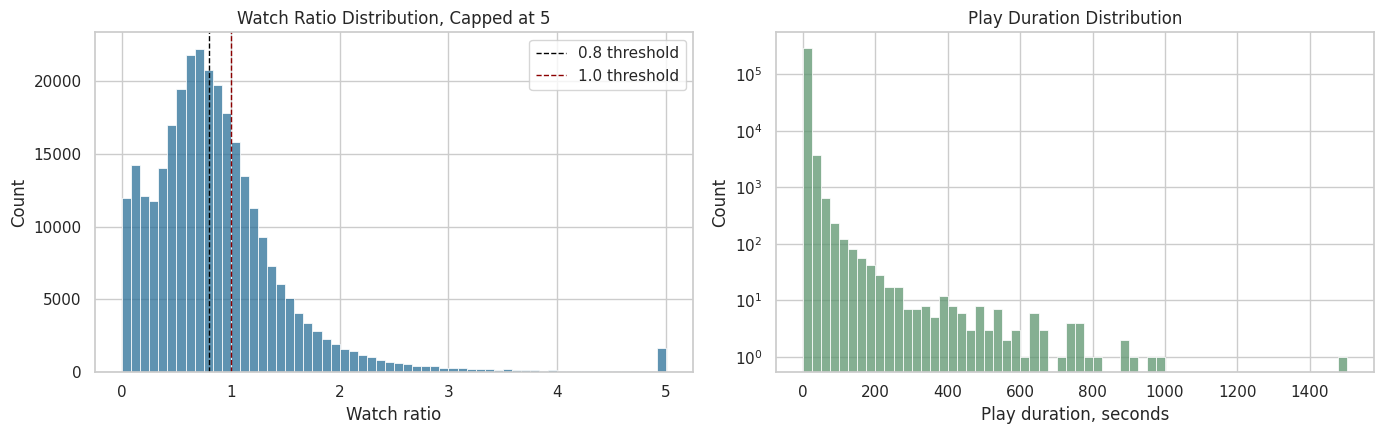

In [12]:
# Visualize short-Term engagement.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(
    data=interactions,
    x="watch_ratio_capped_5",
    bins=60,
    ax=axes[0],
    color="#2A6F97",
)
axes[0].axvline(0.8, color="black", linestyle="--", linewidth=1, label="0.8 threshold")
axes[0].axvline(1.0, color="darkred", linestyle="--", linewidth=1, label="1.0 threshold")
axes[0].set_title("Watch Ratio Distribution, Capped at 5")
axes[0].set_xlabel("Watch ratio")
axes[0].legend()

sns.histplot(
    data=interactions,
    x="play_duration_sec",
    bins=60,
    ax=axes[1],
    color="#5C946E",
)
axes[1].set_title("Play Duration Distribution")
axes[1].set_xlabel("Play duration, seconds")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


The plots make the engagement skew easier to see. The watch-ratio thresholds around 0.8 and 1.0 are plausible anchors for high-watch and over-completion behavior, which motivates the candidate treatment definitions created later.


#### User and Item Repeated Measures

Sequential causal inference needs repeated observations for the same users. If every user appeared once, we would lack histories, lagged confounders, and future retention. The next cell summarizes how many interactions and active days each sampled user contributes, and how concentrated video consumption is across items.


In [13]:
# Prepare user and item repeated measures.
user_activity = (
    interactions.groupby("user_id")
    .agg(
        interactions=("video_id", "size"),
        unique_videos=("video_id", "nunique"),
        active_days=("event_date", "nunique"),
        first_date=("event_date", "min"),
        last_date=("event_date", "max"),
        avg_watch_ratio=("watch_ratio", "mean"),
        total_play_duration_sec=("play_duration_sec", "sum"),
    )
    .reset_index()
)

item_activity = (
    interactions.groupby("video_id")
    .agg(
        impressions=("user_id", "size"),
        unique_users=("user_id", "nunique"),
        avg_watch_ratio=("watch_ratio", "mean"),
        avg_play_duration_sec=("play_duration_sec", "mean"),
    )
    .reset_index()
    .sort_values("impressions", ascending=False)
)

print("User activity summary")
display(user_activity[["interactions", "unique_videos", "active_days", "avg_watch_ratio", "total_play_duration_sec"]].describe().T)

print("Most observed videos in the sample")
display(item_activity.head(10))


User activity summary


,count,mean,std,min,25%,50%,75%,max
interactions,91.0000,"3,296.7033",166.3290,"1,729.0000","3,309.0000","3,315.0000","3,320.0000","3,326.0000"
unique_videos,91.0000,"3,296.7033",166.3290,"1,729.0000","3,309.0000","3,315.0000","3,320.0000","3,326.0000"
active_days,91.0000,60.8462,3.9831,31.0000,61.0000,62.0000,63.0000,63.0000
avg_watch_ratio,91.0000,0.9190,0.1953,0.6512,0.7941,0.8832,0.9841,2.0275
total_play_duration_sec,91.0000,"28,712.8942","6,276.4357","13,711.2750","25,107.3275","28,289.4630","31,055.6880","63,349.6840"


Most observed videos in the sample


,video_id,impressions,unique_users,avg_watch_ratio,avg_play_duration_sec
31,186,91,91,1.1330,7.7613
30,183,91,91,1.6252,9.9136
0,103,91,91,0.7553,7.7798
1,109,91,91,1.0973,8.5228
2,120,91,91,1.9835,12.4414
3,122,91,91,0.8607,8.3776
4,128,91,91,0.7762,8.0989
5,130,91,91,0.8416,8.4340
29,180,91,91,0.8184,9.0079
28,179,91,91,1.2162,7.3785


The user and item summaries show how much repeated information exists per user and how concentrated consumption is across videos. Repeated user histories are the key ingredient for long-term causal effects, while item concentration reminds us that content popularity may be a confounder.


#### Plot Repeated User Activity

The next plots show whether users have enough repeated activity for a user-day panel. The left plot checks interaction volume per user. The right plot checks the number of active calendar days per user. More repeated days means more usable history for later marginal structural modeling.


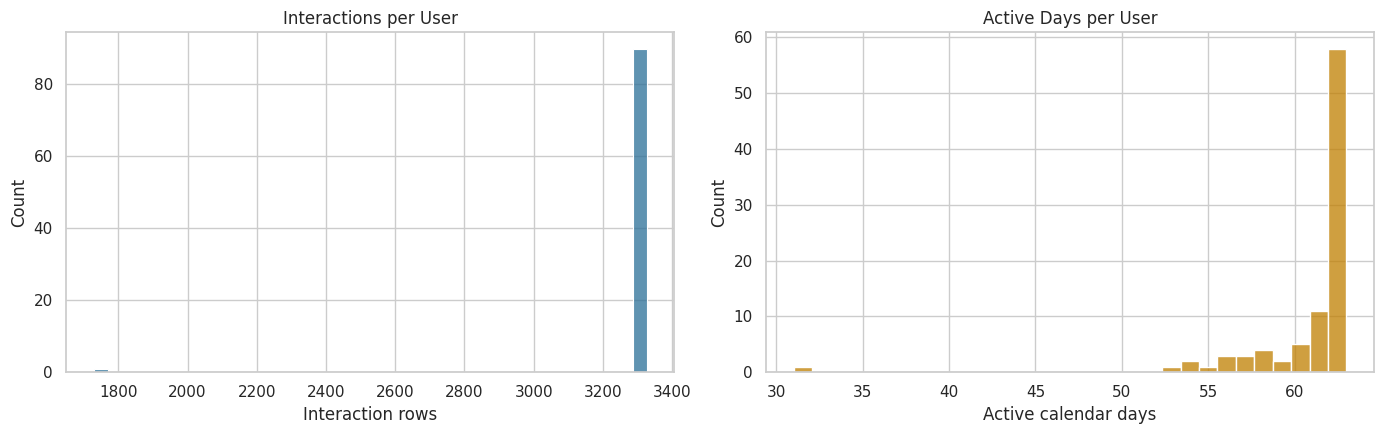

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(data=user_activity, x="interactions", bins=40, ax=axes[0], color="#2A6F97")
axes[0].set_title("Interactions per User")
axes[0].set_xlabel("Interaction rows")

sns.histplot(data=user_activity, x="active_days", bins=30, ax=axes[1], color="#C07F00")
axes[1].set_title("Active Days per User")
axes[1].set_xlabel("Active calendar days")

plt.tight_layout()
plt.show()


The activity plots help verify that users contribute multiple interaction rows and active days. That supports the next move: aggregating events into user-day records so that each row can represent one time step in a longitudinal causal panel.


#### Build the Observed User-Day Table

The raw data is interaction-level. Long-term causal effects are easier to reason about at a user-day level. This cell aggregates each user's activity on each observed day. It creates daily metrics such as total interactions, unique videos, total play duration, average watch ratio, and the share of watched videos that crossed a high-watch threshold.

The high-watch threshold is set at `watch_ratio >= 0.8` as a first-pass operational definition. This still leaves the final treatment definition open. It is a transparent candidate that later notebooks can refine.


In [15]:
# Build the observed user-Day table.
HIGH_WATCH_THRESHOLD = 0.8
COMPLETE_OR_REWATCH_THRESHOLD = 1.0

interactions["high_watch"] = (interactions["watch_ratio"] >= HIGH_WATCH_THRESHOLD).astype(int)
interactions["complete_or_rewatch"] = (interactions["watch_ratio"] >= COMPLETE_OR_REWATCH_THRESHOLD).astype(int)

user_day_observed = (
    interactions.groupby(["user_id", "event_date"])
    .agg(
        interactions=("video_id", "size"),
        unique_videos=("video_id", "nunique"),
        total_play_duration_ms=("play_duration", "sum"),
        avg_play_duration_ms=("play_duration", "mean"),
        avg_video_duration_ms=("video_duration", "mean"),
        avg_watch_ratio=("watch_ratio", "mean"),
        high_watch_count=("high_watch", "sum"),
        complete_or_rewatch_count=("complete_or_rewatch", "sum"),
    )
    .reset_index()
)

user_day_observed["total_play_duration_sec"] = user_day_observed["total_play_duration_ms"] / 1_000
user_day_observed["avg_play_duration_sec"] = user_day_observed["avg_play_duration_ms"] / 1_000
user_day_observed["avg_video_duration_sec"] = user_day_observed["avg_video_duration_ms"] / 1_000
user_day_observed["high_watch_share"] = user_day_observed["high_watch_count"] / user_day_observed["interactions"]
user_day_observed["complete_or_rewatch_share"] = user_day_observed["complete_or_rewatch_count"] / user_day_observed["interactions"]

user_day_observed = user_day_observed.sort_values(["user_id", "event_date"]).reset_index(drop=True)

print(f"Observed user-day rows: {len(user_day_observed):,}")
display(user_day_observed.head(10))


Observed user-day rows: 5,537


,user_id,event_date,interactions,unique_videos,total_play_duration_ms,avg_play_duration_ms,avg_video_duration_ms,avg_watch_ratio,high_watch_count,complete_or_rewatch_count,total_play_duration_sec,avg_play_duration_sec,avg_video_duration_sec,high_watch_share,complete_or_rewatch_share
0,14,2020-07-05,26,26,240975,"9,268.2692","10,187.6538",1.0845,15,12,240.9750,9.2683,10.1877,0.5769,0.4615
1,14,2020-07-06,23,23,248344,"10,797.5652","14,615.2174",1.0640,12,10,248.3440,10.7976,14.6152,0.5217,0.4348
2,14,2020-07-07,78,78,655489,"8,403.7051","13,529.6410",0.8415,36,27,655.4890,8.4037,13.5296,0.4615,0.3462
3,14,2020-07-08,22,22,201901,"9,177.3182","12,657.1818",0.9828,11,9,201.9010,9.1773,12.6572,0.5000,0.4091
4,14,2020-07-09,55,55,485039,"8,818.8909","12,841.6727",0.8619,20,15,485.0390,8.8189,12.8417,0.3636,0.2727
5,14,2020-07-10,52,52,606244,"11,658.5385","17,735.4038",1.1380,30,21,606.2440,11.6585,17.7354,0.5769,0.4038
6,14,2020-07-11,32,32,284747,"8,898.3438","13,858.9688",0.9337,16,10,284.7470,8.8983,13.8590,0.5000,0.3125
7,14,2020-07-12,42,42,337918,"8,045.6667","13,215.6429",0.7986,18,11,337.9180,8.0457,13.2156,0.4286,0.2619
8,14,2020-07-13,46,46,502145,"10,916.1957","13,244.0000",1.0389,24,19,502.1450,10.9162,13.2440,0.5217,0.4130
9,14,2020-07-14,42,42,337489,"8,035.4524","14,600.6190",0.9892,23,16,337.4890,8.0355,14.6006,0.5476,0.3810


The observed user-day table compresses raw events into daily engagement states. This is the first major causal-design transformation: the analysis unit shifts from an individual watch event to a user observed on a calendar day.


#### Densify the User-Day Panel

A long-term outcome like next-day retention requires knowing when a user was inactive. The observed table contains days with at least one interaction, while a dense user-date grid records inactive days explicitly. The next cell creates a dense user-date grid across the sample window and fills missing activity with zeros.

This dense panel lets us define outcomes such as `next_day_active` and `future_7day_active_days`. Those outcomes are central to the long-term causal question because they move beyond immediate watch behavior.


In [16]:
# Densify the user-Day panel.
all_users = np.sort(user_day_observed["user_id"].unique())
all_dates = pd.date_range(
    user_day_observed["event_date"].min(),
    user_day_observed["event_date"].max(),
    freq="D",
)

dense_index = pd.MultiIndex.from_product(
    [all_users, all_dates],
    names=["user_id", "event_date"],
)

user_day = (
    user_day_observed.set_index(["user_id", "event_date"])
    .reindex(dense_index)
    .reset_index()
)

count_and_sum_columns = [
    "interactions",
    "unique_videos",
    "total_play_duration_ms",
    "high_watch_count",
    "complete_or_rewatch_count",
    "total_play_duration_sec",
]
rate_and_average_columns = [
    "avg_play_duration_ms",
    "avg_video_duration_ms",
    "avg_watch_ratio",
    "avg_play_duration_sec",
    "avg_video_duration_sec",
    "high_watch_share",
    "complete_or_rewatch_share",
]

user_day[count_and_sum_columns] = user_day[count_and_sum_columns].fillna(0)
user_day[rate_and_average_columns] = user_day[rate_and_average_columns].fillna(0)
user_day["active_day"] = (user_day["interactions"] > 0).astype(int)

user_day = user_day.sort_values(["user_id", "event_date"]).reset_index(drop=True)

print(f"Dense user-day panel shape: {user_day.shape}")
print(f"Users in panel: {user_day['user_id'].nunique():,}")
print(f"Dates per user: {user_day['event_date'].nunique():,}")
display(user_day.head(10))


Dense user-day panel shape: (5733, 16)
Users in panel: 91
Dates per user: 63


,user_id,event_date,interactions,unique_videos,total_play_duration_ms,avg_play_duration_ms,avg_video_duration_ms,avg_watch_ratio,high_watch_count,complete_or_rewatch_count,total_play_duration_sec,avg_play_duration_sec,avg_video_duration_sec,high_watch_share,complete_or_rewatch_share,active_day
0,14,2020-07-05,26.0000,26.0000,"240,975.0000","9,268.2692","10,187.6538",1.0845,15.0000,12.0000,240.9750,9.2683,10.1877,0.5769,0.4615,1
1,14,2020-07-06,23.0000,23.0000,"248,344.0000","10,797.5652","14,615.2174",1.0640,12.0000,10.0000,248.3440,10.7976,14.6152,0.5217,0.4348,1
2,14,2020-07-07,78.0000,78.0000,"655,489.0000","8,403.7051","13,529.6410",0.8415,36.0000,27.0000,655.4890,8.4037,13.5296,0.4615,0.3462,1
3,14,2020-07-08,22.0000,22.0000,"201,901.0000","9,177.3182","12,657.1818",0.9828,11.0000,9.0000,201.9010,9.1773,12.6572,0.5000,0.4091,1
4,14,2020-07-09,55.0000,55.0000,"485,039.0000","8,818.8909","12,841.6727",0.8619,20.0000,15.0000,485.0390,8.8189,12.8417,0.3636,0.2727,1
5,14,2020-07-10,52.0000,52.0000,"606,244.0000","11,658.5385","17,735.4038",1.1380,30.0000,21.0000,606.2440,11.6585,17.7354,0.5769,0.4038,1
6,14,2020-07-11,32.0000,32.0000,"284,747.0000","8,898.3438","13,858.9688",0.9337,16.0000,10.0000,284.7470,8.8983,13.8590,0.5000,0.3125,1
7,14,2020-07-12,42.0000,42.0000,"337,918.0000","8,045.6667","13,215.6429",0.7986,18.0000,11.0000,337.9180,8.0457,13.2156,0.4286,0.2619,1
8,14,2020-07-13,46.0000,46.0000,"502,145.0000","10,916.1957","13,244.0000",1.0389,24.0000,19.0000,502.1450,10.9162,13.2440,0.5217,0.4130,1
9,14,2020-07-14,42.0000,42.0000,"337,489.0000","8,035.4524","14,600.6190",0.9892,23.0000,16.0000,337.4890,8.0355,14.6006,0.5476,0.3810,1


The dense panel explicitly includes inactive dates, which is necessary for future retention-style outcomes. This prevents missing user-days from being treated as if they were outside the analysis.


#### Add Lagged State Variables

In sequential causal inference, the user's past is part of the confounding structure. A user who watched heavily yesterday may be more likely to receive certain recommendations today and more likely to be active tomorrow. The next cell creates lagged and prior-window features that later notebooks can use as time-varying confounders.

These variables are adjustment and history features. They are the observed state before a daily treatment decision.


In [17]:
# Add lagged state variables.
lag_columns = [
    "active_day",
    "interactions",
    "total_play_duration_sec",
    "avg_watch_ratio",
    "high_watch_share",
]

for column in lag_columns:
    user_day[f"lag_1_{column}"] = user_day.groupby("user_id")[column].shift(1)
    user_day[f"prior_3day_{column}"] = user_day.groupby("user_id")[column].transform(
        lambda series: series.shift(1).rolling(window=3, min_periods=1).sum()
    )

lagged_columns = [column for column in user_day.columns if column.startswith("lag_1_") or column.startswith("prior_3day_")]
user_day[lagged_columns] = user_day[lagged_columns].fillna(0)

state_preview_columns = [
    "user_id",
    "event_date",
    "active_day",
    "interactions",
    "lag_1_active_day",
    "lag_1_interactions",
    "prior_3day_active_day",
    "prior_3day_interactions",
]

display(user_day[state_preview_columns].head(15))


,user_id,event_date,active_day,interactions,lag_1_active_day,lag_1_interactions,prior_3day_active_day,prior_3day_interactions
0,14,2020-07-05,1,26.0000,0.0000,0.0000,0.0000,0.0000
1,14,2020-07-06,1,23.0000,1.0000,26.0000,1.0000,26.0000
2,14,2020-07-07,1,78.0000,1.0000,23.0000,2.0000,49.0000
3,14,2020-07-08,1,22.0000,1.0000,78.0000,3.0000,127.0000
4,14,2020-07-09,1,55.0000,1.0000,22.0000,3.0000,123.0000
5,14,2020-07-10,1,52.0000,1.0000,55.0000,3.0000,155.0000
6,14,2020-07-11,1,32.0000,1.0000,52.0000,3.0000,129.0000
7,14,2020-07-12,1,42.0000,1.0000,32.0000,3.0000,139.0000
8,14,2020-07-13,1,46.0000,1.0000,42.0000,3.0000,126.0000
9,14,2020-07-14,1,42.0000,1.0000,46.0000,3.0000,120.0000


The lagged and prior-window columns capture the user's pre-treatment state. These variables are central to later causal adjustment because prior engagement can influence both today's recommendation exposure and tomorrow's behavior.


#### Add Forward-Looking Outcomes

The next cell creates future outcome variables. These include next-day activity and multi-day future engagement. We keep these outcomes separate from treatment definitions so later notebooks can estimate how candidate treatment patterns affect future behavior.

Rows near the end of the sample window lack enough future days to define all outcomes. Those rows are marked as missing for the affected future horizons.


In [18]:
# Add forward-Looking outcomes.
future_base_columns = ["active_day", "interactions", "total_play_duration_sec"]
future_horizons = [1, 2, 3, 4, 5, 6, 7]

for column in future_base_columns:
    for horizon in future_horizons:
        user_day[f"lead_{horizon}_{column}"] = user_day.groupby("user_id")[column].shift(-horizon)

user_day["next_day_active"] = user_day["lead_1_active_day"]
user_day["next_day_interactions"] = user_day["lead_1_interactions"]
user_day["next_day_play_duration_sec"] = user_day["lead_1_total_play_duration_sec"]

user_day["future_3day_active_days"] = user_day[[f"lead_{horizon}_active_day" for horizon in [1, 2, 3]]].sum(axis=1, min_count=3)
user_day["future_3day_interactions"] = user_day[[f"lead_{horizon}_interactions" for horizon in [1, 2, 3]]].sum(axis=1, min_count=3)
user_day["future_3day_play_duration_sec"] = user_day[[f"lead_{horizon}_total_play_duration_sec" for horizon in [1, 2, 3]]].sum(axis=1, min_count=3)

user_day["future_7day_active_days"] = user_day[[f"lead_{horizon}_active_day" for horizon in future_horizons]].sum(axis=1, min_count=7)
user_day["future_7day_interactions"] = user_day[[f"lead_{horizon}_interactions" for horizon in future_horizons]].sum(axis=1, min_count=7)
user_day["future_7day_play_duration_sec"] = user_day[[f"lead_{horizon}_total_play_duration_sec" for horizon in future_horizons]].sum(axis=1, min_count=7)

outcome_preview_columns = [
    "user_id",
    "event_date",
    "active_day",
    "interactions",
    "next_day_active",
    "future_3day_active_days",
    "future_3day_interactions",
    "future_7day_active_days",
]

display(user_day[outcome_preview_columns].head(15))


,user_id,event_date,active_day,interactions,next_day_active,future_3day_active_days,future_3day_interactions,future_7day_active_days
0,14,2020-07-05,1,26.0000,1.0000,3.0000,123.0000,7.0000
1,14,2020-07-06,1,23.0000,1.0000,3.0000,155.0000,7.0000
2,14,2020-07-07,1,78.0000,1.0000,3.0000,129.0000,7.0000
3,14,2020-07-08,1,22.0000,1.0000,3.0000,139.0000,7.0000
4,14,2020-07-09,1,55.0000,1.0000,3.0000,126.0000,7.0000
5,14,2020-07-10,1,52.0000,1.0000,3.0000,120.0000,7.0000
6,14,2020-07-11,1,32.0000,1.0000,3.0000,130.0000,7.0000
7,14,2020-07-12,1,42.0000,1.0000,3.0000,98.0000,7.0000
8,14,2020-07-13,1,46.0000,1.0000,3.0000,139.0000,7.0000
9,14,2020-07-14,1,42.0000,1.0000,3.0000,190.0000,7.0000


The lead columns and future-window outcomes give the project its long-term target. Current-day behavior can now be related to next-day, 3-day, and 7-day future engagement while keeping future information out of the confounder set.


#### Candidate Treatment Definitions

For this project, a treatment is a daily user-day exposure pattern generated by a recommender system. At this stage, we define two transparent candidate treatments:

- `treatment_high_intensity`: the user had an active day with interaction count in the upper quartile of active days.
- `treatment_high_watch_exposure`: the user had an active day where the share of high-watch videos was above the median active-day share.

These are simple first definitions. They give us a concrete way to inspect treatment variation and confounding before more sophisticated modeling.


In [19]:
# Prepare candidate treatment definitions.
active_user_days = user_day["active_day"] == 1

high_intensity_threshold = user_day.loc[active_user_days, "interactions"].quantile(0.75)
high_watch_share_threshold = user_day.loc[active_user_days, "high_watch_share"].median()

user_day["treatment_high_intensity"] = (
    active_user_days & (user_day["interactions"] >= high_intensity_threshold)
).astype(int)
user_day["treatment_high_watch_exposure"] = (
    active_user_days & (user_day["high_watch_share"] >= high_watch_share_threshold)
).astype(int)

thresholds = pd.DataFrame(
    [
        {
            "candidate_treatment": "treatment_high_intensity",
            "rule": "active day and interactions >= active-day 75th percentile",
            "threshold": high_intensity_threshold,
        },
        {
            "candidate_treatment": "treatment_high_watch_exposure",
            "rule": "active day and high_watch_share >= active-day median",
            "threshold": high_watch_share_threshold,
        },
    ]
)

treatment_summary = user_day[
    ["treatment_high_intensity", "treatment_high_watch_exposure"]
].agg(["mean", "sum"]).T.rename(columns={"mean": "share_of_user_days", "sum": "treated_user_days"})

display(thresholds)
display(treatment_summary)


,candidate_treatment,rule,threshold
0,treatment_high_intensity,active day and interactions >= active-day 75th...,70.0000
1,treatment_high_watch_exposure,active day and high_watch_share >= active-day ...,0.4773


,share_of_user_days,treated_user_days
treatment_high_intensity,0.2501,"1,434.0000"
treatment_high_watch_exposure,0.4842,"2,776.0000"


The treatment summary shows whether the first two exposure definitions have usable variation. These simple definitions let us test whether the data can support a treated-versus-control comparison before committing to a final estimand.


#### Plot Daily Treatment and Outcome Rates

This plot checks whether the candidate treatments and next-day activity vary over time. A useful causal study needs variation. If a treatment is always on, always off, or perfectly aligned with a single date, it is hard to estimate a meaningful effect.


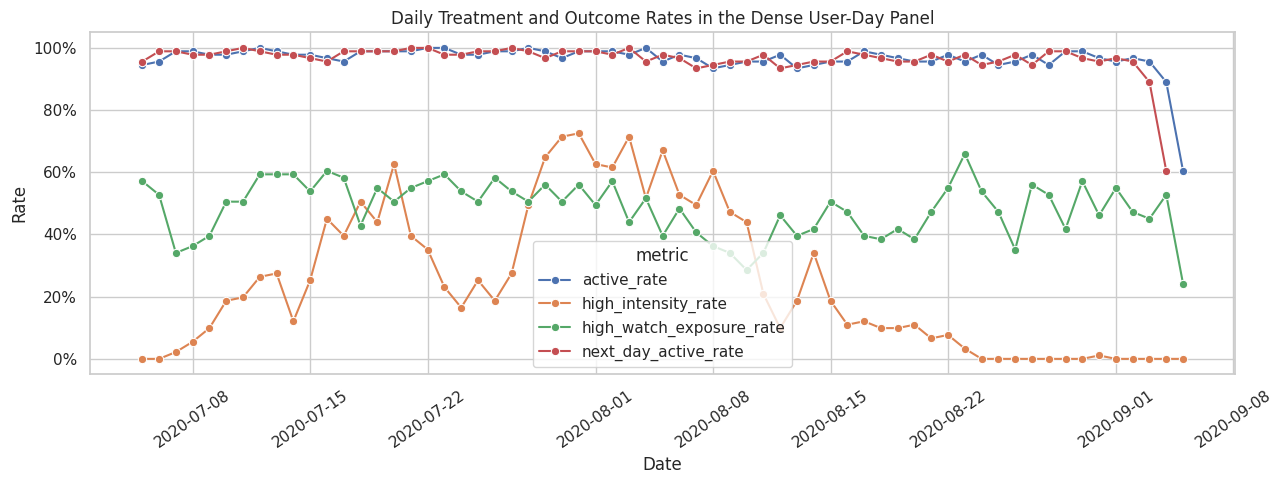

In [20]:
# Plot daily treatment and outcome rates.
daily_panel_summary = (
    user_day.groupby("event_date")
    .agg(
        active_rate=("active_day", "mean"),
        high_intensity_rate=("treatment_high_intensity", "mean"),
        high_watch_exposure_rate=("treatment_high_watch_exposure", "mean"),
        next_day_active_rate=("next_day_active", "mean"),
    )
    .reset_index()
)

plot_daily = daily_panel_summary.melt(
    id_vars="event_date",
    value_vars=["active_rate", "high_intensity_rate", "high_watch_exposure_rate", "next_day_active_rate"],
    var_name="metric",
    value_name="rate",
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=plot_daily, x="event_date", y="rate", hue="metric", marker="o", linewidth=1.5, ax=ax)
ax.set_title("Daily Treatment and Outcome Rates in the Dense User-Day Panel")
ax.set_xlabel("Date")
ax.set_ylabel("Rate")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


The time-series plot checks whether treatment and outcome rates vary over the calendar window. If treatment prevalence changed sharply by date, later models would need calendar controls; this plot starts that diagnostic conversation.


#### Naive Associations Need Adjustment

The next table compares future outcomes between treated and untreated active user-days. This is useful as a descriptive diagnostic before causal estimation. Treated days are likely different before treatment happens. For example, users with high activity today may already be more engaged, and that prior engagement may predict future activity regardless of today's exposure.

The purpose of this table is to create intuition and motivate the confounding checks that follow.


In [21]:
# Naive associations are not causal effects.
def summarize_naive_association(data, treatment_col, outcome_cols):
    """
    Summarize naive treatment-outcome differences.
    
    Idea
    ----
    The helper gives a descriptive baseline before adjustment, making clear how much of the apparent long-term effect may be confounded by user history.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    treatment_col : object
        Column indicating treatment or exposure status.
    outcome_cols : object
        Outcome columns to summarize or model.
    
    Returns
    -------
    pandas.DataFrame
        Outcome means and naive differences by treatment group.
    """
    rows = []
    analytic = data.loc[data["active_day"].eq(1)].copy()
    for outcome_col in outcome_cols:
        subset = analytic.dropna(subset=[treatment_col, outcome_col])
        grouped = subset.groupby(treatment_col)[outcome_col].agg(["mean", "count", "std"])
        if set(grouped.index) >= {0, 1}:
            control_mean = grouped.loc[0, "mean"]
            treated_mean = grouped.loc[1, "mean"]
            rows.append(
                {
                    "treatment": treatment_col,
                    "outcome": outcome_col,
                    "control_mean": control_mean,
                    "treated_mean": treated_mean,
                    "difference": treated_mean - control_mean,
                    "relative_lift": (treated_mean / control_mean - 1) if control_mean != 0 else np.nan,
                    "control_days": grouped.loc[0, "count"],
                    "treated_days": grouped.loc[1, "count"],
                }
            )
    return pd.DataFrame(rows)

outcome_columns = [
    "next_day_active",
    "future_3day_active_days",
    "future_3day_interactions",
    "future_7day_active_days",
]

naive_associations = pd.concat(
    [
        summarize_naive_association(user_day, "treatment_high_intensity", outcome_columns),
        summarize_naive_association(user_day, "treatment_high_watch_exposure", outcome_columns),
    ],
    ignore_index=True,
)

display(naive_associations)


,treatment,outcome,control_mean,treated_mean,difference,relative_lift,control_days,treated_days
0,treatment_high_intensity,next_day_active,0.9750,0.9868,0.0117,0.0120,4048,1434
1,treatment_high_intensity,future_3day_active_days,2.9371,2.9477,0.0106,0.0036,3880,1434
2,treatment_high_intensity,future_3day_interactions,138.8616,207.0342,68.1726,0.4909,3880,1434
3,treatment_high_intensity,future_7day_active_days,6.8580,6.8562,-0.0017,-0.0003,3528,1433
4,treatment_high_watch_exposure,next_day_active,0.9835,0.9728,-0.0107,-0.0109,2728,2754
5,treatment_high_watch_exposure,future_3day_active_days,2.9479,2.9321,-0.0158,-0.0054,2649,2665
6,treatment_high_watch_exposure,future_3day_interactions,157.7493,156.7700,-0.9794,-0.0062,2649,2665
7,treatment_high_watch_exposure,future_7day_active_days,6.8719,6.8430,-0.0289,-0.0042,2483,2478


The naive comparisons describe how future outcomes differ between treated and untreated days. They should be read descriptively. Their value is motivational. Visible differences raise the question of whether those differences remain after accounting for prior user state.


#### Check Time-Varying Confounding

A major reason this project needs causal methods is that prior user state can affect both today's treatment and future outcomes. The next cell computes standardized mean differences for pre-treatment covariates between treated and untreated active days. Large imbalances mean that a naive treated-versus-control comparison is likely confounded.

A standardized mean difference is the treated-control difference in means divided by a pooled standard deviation. Values far from zero indicate imbalance in the pre-treatment state.


In [22]:
# Check time-Varying confounding.
def standardized_mean_differences(data, treatment_col, covariate_cols):
    """
    Compute standardized mean differences for several covariates.
    
    Idea
    ----
    This summarizes observed treated-control imbalance across the covariates used for adjustment in the sequential causal panel.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    treatment_col : object
        Column indicating treatment or exposure status.
    covariate_cols : object
        Covariate columns to summarize for balance.
    
    Returns
    -------
    pandas.DataFrame
        One row per covariate with treated means, control means, and standardized differences.
    """
    analytic = data.loc[data["active_day"].eq(1)].dropna(subset=[treatment_col]).copy()
    rows = []
    for covariate in covariate_cols:
        treated = analytic.loc[analytic[treatment_col].eq(1), covariate].dropna()
        control = analytic.loc[analytic[treatment_col].eq(0), covariate].dropna()
        pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
        rows.append(
            {
                "treatment": treatment_col,
                "covariate": covariate,
                "treated_mean": treated.mean(),
                "control_mean": control.mean(),
                "smd": (treated.mean() - control.mean()) / pooled_sd if pooled_sd and not np.isnan(pooled_sd) else np.nan,
            }
        )
    return pd.DataFrame(rows)

pre_treatment_covariates = [
    "lag_1_active_day",
    "lag_1_interactions",
    "lag_1_total_play_duration_sec",
    "lag_1_avg_watch_ratio",
    "prior_3day_active_day",
    "prior_3day_interactions",
    "prior_3day_total_play_duration_sec",
    "prior_3day_high_watch_share",
]

confounding_balance = pd.concat(
    [
        standardized_mean_differences(user_day, "treatment_high_intensity", pre_treatment_covariates),
        standardized_mean_differences(user_day, "treatment_high_watch_exposure", pre_treatment_covariates),
    ],
    ignore_index=True,
)

display(confounding_balance.sort_values(["treatment", "smd"], key=lambda col: col.abs() if col.name == "smd" else col))


,treatment,covariate,treated_mean,control_mean,smd
3,treatment_high_intensity,lag_1_avg_watch_ratio,0.9103,0.9208,-0.0193
0,treatment_high_intensity,lag_1_active_day,0.9770,0.9654,0.0694
7,treatment_high_intensity,prior_3day_high_watch_share,1.4207,1.3741,0.1029
4,treatment_high_intensity,prior_3day_active_day,2.9303,2.8279,0.2198
2,treatment_high_intensity,lag_1_total_play_duration_sec,617.3946,388.2157,0.7200
6,treatment_high_intensity,prior_3day_total_play_duration_sec,"1,794.1988","1,177.3717",0.8370
1,treatment_high_intensity,lag_1_interactions,71.7364,44.2764,0.8406
5,treatment_high_intensity,prior_3day_interactions,207.7497,134.4448,1.0026
8,treatment_high_watch_exposure,lag_1_active_day,0.9672,0.9696,-0.0135
12,treatment_high_watch_exposure,prior_3day_active_day,2.8483,2.8606,-0.0232


The standardized mean differences show whether treated and untreated days already looked different before treatment. Any meaningful imbalance here supports the central claim of the project. Sequential recommender logs need causal adjustment alongside outcome comparison.


#### Visualize Covariate Imbalance

The heatmap below gives a quick visual read of confounding. Darker positive or negative values mean treated and untreated active days had different histories before the treatment day. This is exactly the kind of structure that motivates marginal structural models and g-computation in later notebooks.


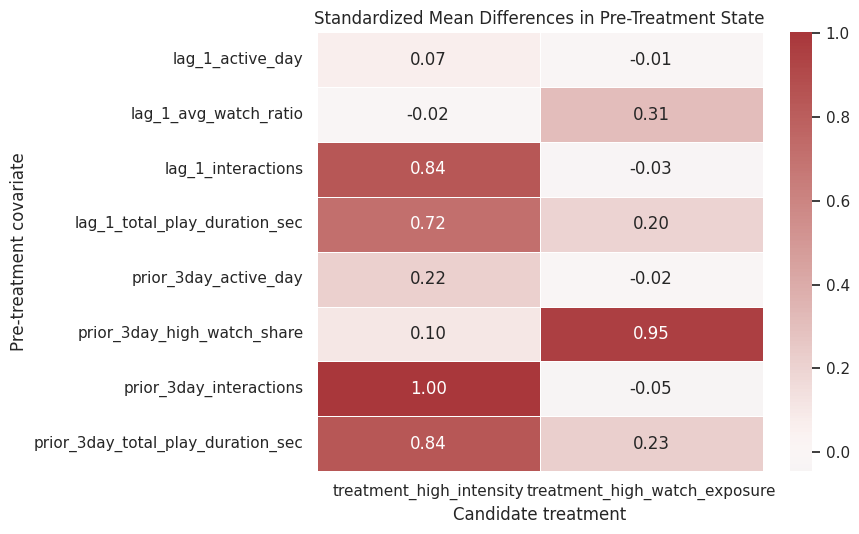

In [23]:
balance_heatmap = confounding_balance.pivot(index="covariate", columns="treatment", values="smd")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(
    balance_heatmap,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Standardized Mean Differences in Pre-Treatment State")
ax.set_xlabel("Candidate treatment")
ax.set_ylabel("Pre-treatment covariate")
plt.tight_layout()
plt.show()


The heatmap turns the balance table into a quick diagnostic. Larger color contrasts indicate pre-treatment differences that later notebooks must address with propensity models, marginal structural models, or g-computation.


#### Join Metadata for Diagnostic Checks

User metadata can help explain why treatment assignment differs across users. The next cell joins the interaction sample to user activity segment and item category features. This is a sanity check that the metadata keys connect cleanly to the interaction log before the final feature engineering step.


In [24]:
# Join metadata for diagnostic checks.
user_metadata_columns = [
    "user_id",
    "user_active_degree",
    "is_lowactive_period",
    "is_live_streamer",
    "is_video_author",
    "follow_user_num",
    "fans_user_num",
    "friend_user_num",
    "register_days",
]

interaction_metadata_sample = (
    interactions.merge(user_features[user_metadata_columns], on="user_id", how="left")
    .merge(item_categories[["video_id", "category_count", "first_category"]], on="video_id", how="left")
)

metadata_diagnostics = pd.DataFrame(
    [
        {"metric": "rows", "value": len(interaction_metadata_sample)},
        {"metric": "missing_user_active_degree_rate", "value": interaction_metadata_sample["user_active_degree"].isna().mean()},
        {"metric": "missing_item_category_rate", "value": interaction_metadata_sample["category_count"].isna().mean()},
        {"metric": "unique_user_activity_segments", "value": interaction_metadata_sample["user_active_degree"].nunique(dropna=True)},
        {"metric": "unique_first_categories", "value": interaction_metadata_sample["first_category"].nunique(dropna=True)},
    ]
)

display(metadata_diagnostics)

display(
    interaction_metadata_sample.groupby("user_active_degree")
    .agg(
        rows=("video_id", "size"),
        users=("user_id", "nunique"),
        avg_watch_ratio=("watch_ratio", "mean"),
        avg_play_duration_sec=("play_duration_sec", "mean"),
    )
    .sort_values("rows", ascending=False)
)


,metric,value
0,rows,"300,000.0000"
1,missing_user_active_degree_rate,0.0000
2,missing_item_category_rate,0.0000
3,unique_user_activity_segments,3.0000
4,unique_first_categories,30.0000


,rows,users,avg_watch_ratio,avg_play_duration_sec
user_active_degree,,,,
full_active,230406,70,0.9199,8.7178
high_active,62965,19,0.9250,8.7592
UNKNOWN,6629,2,0.8329,7.9533


The join diagnostics confirm that user metadata and item categories connect to the sampled interaction log. This means later models can enrich the history-only panel with baseline user context or item context if the causal design needs more complete adjustment.


#### Inspect Item Daily Popularity Features

Item daily features can be useful later because recommendation exposure is often influenced by item popularity. A popular item may be more likely to be shown, and popular items may also generate different future engagement. The next cell summarizes the sampled item daily table and checks the distribution of simple popularity rates.


,count,mean,std,min,5%,25%,50%,75%,95%,max
show_cnt,"150,000.0000","99,455.6275","565,375.6798",0.0000,3.0000,74.0000,"1,762.0000","28,220.0000","415,838.5500","36,053,957.0000"
show_user_num,"150,000.0000","93,436.8595","542,642.7612",0.0000,3.0000,63.0000,"1,474.0000","25,346.0000","387,015.8000","34,875,019.0000"
play_cnt,"150,000.0000","99,323.0334","584,500.5090",0.0000,0.0000,19.0000,892.0000,"24,438.0000","413,801.5000","37,966,319.0000"
play_user_num,"150,000.0000","89,345.7759","534,001.9580",0.0000,0.0000,16.0000,736.0000,"21,404.2500","369,398.3500","34,501,624.0000"
complete_play_cnt,"150,000.0000","54,362.3796","354,878.3167",0.0000,0.0000,5.0000,306.0000,"10,966.2500","216,402.5500","23,892,867.0000"
like_cnt,"150,000.0000","2,972.5705","18,322.5665",0.0000,0.0000,0.0000,13.0000,521.2500,"12,800.1000","1,286,185.0000"
comment_cnt,"150,000.0000",130.1410,"1,613.5446",0.0000,0.0000,0.0000,0.0000,11.0000,363.0000,"182,959.0000"
share_cnt,"150,000.0000",72.2995,"1,050.6124",0.0000,0.0000,0.0000,0.0000,4.0000,157.0000,"172,181.0000"
collect_cnt,"116,617.0000",14.5537,187.7763,0.0000,0.0000,0.0000,0.0000,1.0000,39.0000,"41,399.0000"
item_play_rate,"149,659.0000",0.6062,0.4483,0.0000,0.0000,0.2485,0.6210,0.9876,1.0405,38.0000


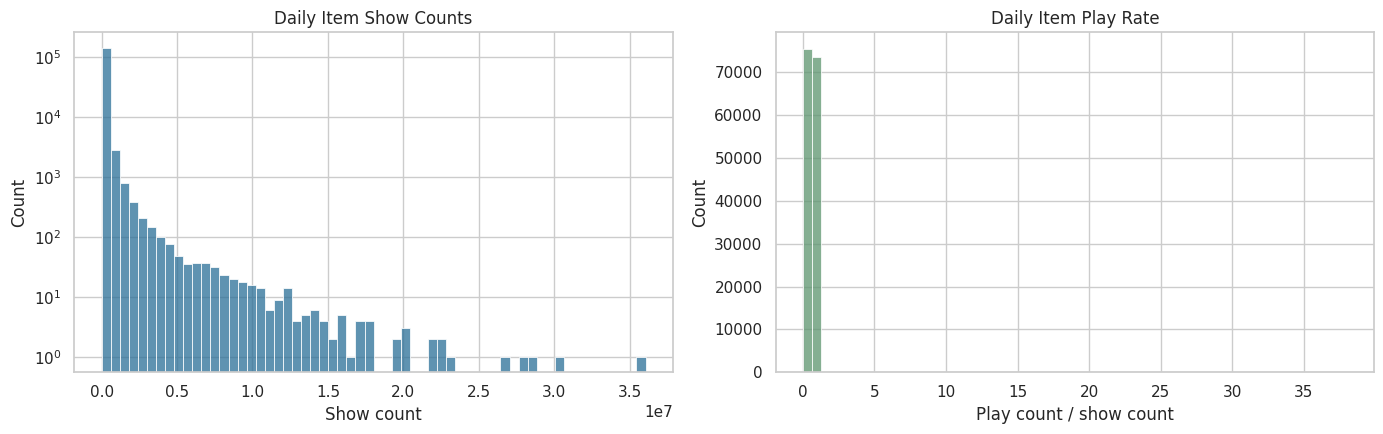

In [25]:
# Inspect item daily popularity features.
item_daily_summary = item_daily[
    [
        "show_cnt",
        "show_user_num",
        "play_cnt",
        "play_user_num",
        "complete_play_cnt",
        "like_cnt",
        "comment_cnt",
        "share_cnt",
        "collect_cnt",
        "item_play_rate",
        "item_like_rate_per_play",
    ]
].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

display(item_daily_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(data=item_daily, x="show_cnt", bins=60, ax=axes[0], color="#2A6F97")
axes[0].set_title("Daily Item Show Counts")
axes[0].set_xlabel("Show count")
axes[0].set_yscale("log")

sns.histplot(data=item_daily, x="item_play_rate", bins=60, ax=axes[1], color="#5C946E")
axes[1].set_title("Daily Item Play Rate")
axes[1].set_xlabel("Play count / show count")

plt.tight_layout()
plt.show()


The item-daily summaries show that item popularity is highly uneven. That unevenness matters because popular videos may be more likely to be recommended and may also produce different engagement patterns, making popularity a potential confounder or stratification variable.


#### Causal Readiness Checklist

This checklist summarizes whether the current sample is adequate for the next stage of the project. The checks focus on the practical requirements for causal modeling. Do we have repeated users, a usable time span, treatment variation, future outcome availability, and pre-treatment state variables? Passing these checks supports moving to formal modeling.


In [26]:
# Prepare causal readiness checklist.
active_days_per_user = user_day.groupby("user_id")["active_day"].sum()
future_3day_available = user_day["future_3day_active_days"].notna().mean()
future_7day_available = user_day["future_7day_active_days"].notna().mean()

treatment_rates = user_day[["treatment_high_intensity", "treatment_high_watch_exposure"]].mean()

readiness_checks = pd.DataFrame(
    [
        {
            "check": "at least 50 users in sample",
            "value": user_day["user_id"].nunique(),
            "passes": user_day["user_id"].nunique() >= 50,
        },
        {
            "check": "median user has at least 7 active days",
            "value": active_days_per_user.median(),
            "passes": active_days_per_user.median() >= 7,
        },
        {
            "check": "at least 30 calendar dates",
            "value": user_day["event_date"].nunique(),
            "passes": user_day["event_date"].nunique() >= 30,
        },
        {
            "check": "high-intensity treatment has non-trivial variation",
            "value": treatment_rates["treatment_high_intensity"],
            "passes": 0.01 < treatment_rates["treatment_high_intensity"] < 0.99,
        },
        {
            "check": "high-watch treatment has non-trivial variation",
            "value": treatment_rates["treatment_high_watch_exposure"],
            "passes": 0.01 < treatment_rates["treatment_high_watch_exposure"] < 0.99,
        },
        {
            "check": "future 3-day outcomes available for most rows",
            "value": future_3day_available,
            "passes": future_3day_available >= 0.80,
        },
        {
            "check": "future 7-day outcomes available for most rows",
            "value": future_7day_available,
            "passes": future_7day_available >= 0.70,
        },
        {
            "check": "lagged confounders have no missing values after filling panel starts",
            "value": user_day[pre_treatment_covariates].isna().mean().max(),
            "passes": user_day[pre_treatment_covariates].isna().mean().max() == 0,
        },
    ]
)

display(readiness_checks)


,check,value,passes
0,at least 50 users in sample,91.0000,True
1,median user has at least 7 active days,62.0000,True
2,at least 30 calendar dates,63.0000,True
3,high-intensity treatment has non-trivial varia...,0.2501,True
4,high-watch treatment has non-trivial variation,0.4842,True
5,future 3-day outcomes available for most rows,0.9524,True
6,future 7-day outcomes available for most rows,0.8889,True
7,lagged confounders have no missing values afte...,0.0000,True


The readiness checklist condenses the EDA into practical criteria for causal modeling. Passing these checks shows that the sample has enough users, time, treatment variation, and future outcomes to justify moving to formal estimand definition.


In [ ]:
#| include: false
interaction_output = PROCESSED_DIR / "kuairec_small_interactions_sample.parquet"
user_day_output = PROCESSED_DIR / "kuairec_user_day_panel_sample.parquet"
readiness_output = PROCESSED_DIR / "kuairec_sequence_eda_readiness.csv"

interactions.to_parquet(interaction_output, index=False)
user_day.to_parquet(user_day_output, index=False)
readiness_checks.to_csv(readiness_output, index=False)

print("Saved processed files:")
print(f"- {interaction_output}")
print(f"- {user_day_output}")
print(f"- {readiness_output}")


The saved files are the handoff from raw EDA to causal design. Future notebooks can load the cleaned interaction sample and dense user-day panel directly, which keeps the project modular and avoids repeating expensive archive parsing.


## Takeaways and Next Step

This notebook turns KuaiRec from a raw interaction log into a sequential causal analysis dataset. The key object is the dense user-day panel. It contains the current day's activity, prior user state, candidate treatment definitions, and future outcomes.

The descriptive comparisons in this notebook motivate adjusted estimators before causal interpretation. They show why causal methods are needed. The confounding checks make the main issue visible: treatment days and non-treatment days differ in their pre-treatment histories. The next notebook should formalize the long-term outcome definitions and decide which treatment-outcome pair will be the primary estimand for the project.
